# Assignment 4: PCA as a Rotation — Not a Distortion

I kept hearing that "PCA rotates the coordinate system" but it did not fully click until I actually drew it. This assignment is about building that visual intuition — the data does not move, only the axes do.

## Step 1: Generate Some Correlated 2D Data

Same setup as before — a 2D Gaussian with a positive off-diagonal covariance so the cloud has a clear lean to it. This is exactly the kind of data where PCA's rotation is most visible.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

np.random.seed(42)

# Correlated 2D Gaussian: strong positive correlation between x1 and x2
mean = [0, 0]
cov  = [[3, 2.2],
        [2.2, 2]]

X = np.random.multivariate_normal(mean, cov, size=300)

print(f"Dataset shape : {X.shape}")
print(f"Sample mean   : {X.mean(axis=0).round(3)}")
print(f"Sample cov    :\n{np.cov(X.T).round(3)}")

Dataset shape : (300, 2)
Sample mean   : [0.023 0.008]
Sample cov    :
[[2.888 2.11 ]
 [2.11  1.901]]


## Step 2: Find the PCA Axes (Manual Eigendecomposition)

I am not using sklearn here — I want to see the eigenvectors directly. Once I center the data and compute the covariance matrix, the eigenvectors *are* the new PCA axes. The one with the larger eigenvalue points in the direction of maximum variance and becomes PC1.

In [2]:
# Center the data
X_mean    = X.mean(axis=0)
X_centered = X - X_mean

# Covariance matrix and eigen-decomposition
C = np.cov(X_centered.T)
eigenvalues, eigenvectors = np.linalg.eig(C)

# Sort by descending eigenvalue
order        = np.argsort(eigenvalues)[::-1]
eigenvalues  = eigenvalues[order].real
eigenvectors = eigenvectors[:, order].real   # columns = PC directions

pc1 = eigenvectors[:, 0]   # direction of maximum variance
pc2 = eigenvectors[:, 1]   # orthogonal direction

print(f"PC1 direction : {pc1.round(4)}  (Lambda1 = {eigenvalues[0]:.4f})")
print(f"PC2 direction : {pc2.round(4)}  (Lambda2 = {eigenvalues[1]:.4f})")
print(f"\nVariance explained — PC1: {eigenvalues[0]/eigenvalues.sum()*100:.1f}%  |  PC2: {eigenvalues[1]/eigenvalues.sum()*100:.1f}%")
print(f"PC1 · PC2 = {pc1 @ pc2:.6f}  (should be ~0, confirming orthogonality)")

PC1 direction : [0.7835 0.6214]  (Lambda1 = 4.5611)
PC2 direction : [-0.6214  0.7835]  (Lambda2 = 0.2279)

Variance explained — PC1: 95.2%  |  PC2: 4.8%
PC1 · PC2 = 0.000000  (should be ~0, confirming orthogonality)


## Step 3: Draw Both Axis Systems on the Same Plot

This is the plot I actually wanted to make. The gray dashed lines are the original x₁/x₂ axes — standard orientation. The colored arrows are PC1 and PC2 — the rotated axes that align with the cloud's natural spread. You can see the original axes don't match the data's shape, but the PCA axes do.

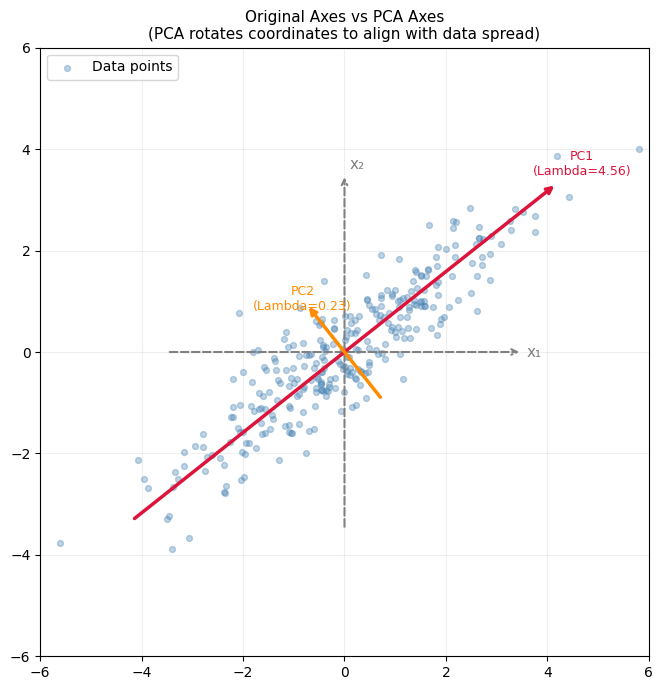

In [3]:
fig, ax = plt.subplots(figsize=(7, 7))

# Scatter: original data (centered for cleaner axis alignment)
ax.scatter(X_centered[:, 0], X_centered[:, 1],
           alpha=0.35, s=18, color='steelblue', zorder=2, label='Data points')

# --- Original axes (standard basis) ---
axis_len = 3.5
ax.annotate('', xy=(axis_len, 0), xytext=(-axis_len, 0),
            arrowprops=dict(arrowstyle='->', color='gray', lw=1.5, linestyle='dashed'))
ax.annotate('', xy=(0, axis_len), xytext=(0, -axis_len),
            arrowprops=dict(arrowstyle='->', color='gray', lw=1.5, linestyle='dashed'))
ax.text(axis_len + 0.1, 0,    'x₁', color='gray', fontsize=11, va='center')
ax.text(0.1,  axis_len + 0.1, 'x₂', color='gray', fontsize=11)

# --- PCA axes (eigenvectors scaled by sqrt(eigenvalue)) ---
for i, (pc, val, color, label) in enumerate(
        zip([pc1, pc2], eigenvalues, ['crimson', 'darkorange'], ['PC1', 'PC2'])):
    scale = np.sqrt(val) * 2.5
    ax.annotate('', xy=scale * pc, xytext=-scale * pc,
                arrowprops=dict(arrowstyle='->', color=color, lw=2.5))
    ax.text(*(scale * pc * 1.12), f'{label}\n(Lambda={val:.2f})',
            color=color, fontsize=9, ha='center', va='center')

ax.set_xlim(-6, 6)
ax.set_ylim(-6, 6)
ax.set_aspect('equal')
ax.set_title('Original Axes vs PCA Axes\n(PCA rotates coordinates to align with data spread)', fontsize=11)
ax.legend(loc='upper left')
ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.savefig('../output/pca_assignment_4_axes.png', dpi=150)
plt.show()

## Step 4: Project into the Rotated Frame and Check the Covariance

Now I project the data onto the PCA axes to get the rotated coordinates. In the new frame, the cloud should look "boring" — an axis-aligned ellipse with no tilt. The off-diagonal covariance should drop to near zero. Let me verify that actually happens.

In [4]:
# Rotate: project centered data onto PCA axes
X_rotated = X_centered @ eigenvectors   # shape (300, 2)

print("Covariance in ORIGINAL space (should show correlation):")
print(np.cov(X_centered.T).round(3))

print("\nCovariance in ROTATED (PCA) space (off-diagonal should be ~0):")
print(np.cov(X_rotated.T).round(3))

Covariance in ORIGINAL space (should show correlation):
[[2.888 2.11 ]
 [2.11  1.901]]

Covariance in ROTATED (PCA) space (off-diagonal should be ~0):
[[4.561 0.   ]
 [0.    0.228]]


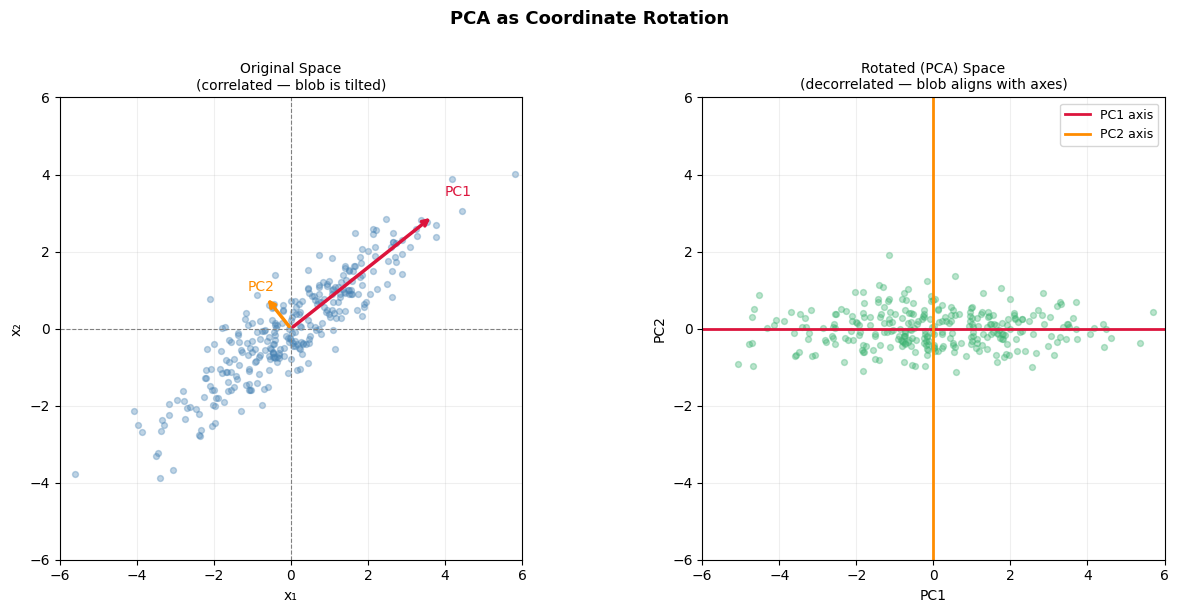

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 6))

# --- Left: Original space ---
ax = axes[0]
ax.scatter(X_centered[:, 0], X_centered[:, 1],
           alpha=0.35, s=18, color='steelblue')
# draw PCA axes onto original space
for pc, val, color, lbl in zip([pc1, pc2], eigenvalues,
                                ['crimson', 'darkorange'], ['PC1', 'PC2']):
    scale = np.sqrt(val) * 2.2
    ax.annotate('', xy=scale * pc, xytext=(0, 0),
                arrowprops=dict(arrowstyle='->', color=color, lw=2.5))
    ax.text(*(scale * pc * 1.18), lbl, color=color, fontsize=10, ha='center')
ax.axhline(0, color='gray', lw=0.8, ls='--')
ax.axvline(0, color='gray', lw=0.8, ls='--')
ax.set_xlim(-6, 6); ax.set_ylim(-6, 6)
ax.set_aspect('equal')
ax.set_title('Original Space\n(correlated — blob is tilted)', fontsize=10)
ax.set_xlabel('x₁'); ax.set_ylabel('x₂')
ax.grid(True, alpha=0.2)

# --- Right: Rotated (PCA) space ---
ax = axes[1]
ax.scatter(X_rotated[:, 0], X_rotated[:, 1],
           alpha=0.35, s=18, color='mediumseagreen')
ax.axhline(0, color='crimson',     lw=2,   label='PC1 axis')
ax.axvline(0, color='darkorange',  lw=2,   label='PC2 axis')
ax.set_xlim(-6, 6); ax.set_ylim(-6, 6)
ax.set_aspect('equal')
ax.set_title('Rotated (PCA) Space\n(decorrelated — blob aligns with axes)', fontsize=10)
ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
ax.legend(loc='upper right', fontsize=9)
ax.grid(True, alpha=0.2)

plt.suptitle('PCA as Coordinate Rotation', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../output/pca_assignment_4_rotation.png', dpi=150, bbox_inches='tight')
plt.show()